#### [ CNN wildfire MODEL]

[1] 모듈 로딩 및 데이터 준비<hr>

In [419]:
## 모듈 로딩
import torch                                        ## Tensor 및 기본 함수들 관련 모듈
import torch.nn as nn                               ## 인공신경망 관련 모듈
import torch.nn.functional as F # type: ignore
import torch.optim as optim 
from   torch.optim.lr_scheduler import ReduceLROnPlateau
from   torchmetrics.classification import *

from torchvision.datasets import FashionMNIST       ## 비젼관련 내장 데이터셋 모듈
from torch.utils.data import DataLoader             ## Pytorch의 데이터셋 관련 모듈
from torchinfo import summary                       ## 모델 구조 및 정보 확인 모듈

import torchvision.transforms as transforms         ## 비젼관련 이미지 증강/변환 관련 모듈

import matplotlib.pyplot as plt                     ## 이미지 시각화 

from torchvision.datasets import ImageFolder            ## 이미지용 데이터셋 생성 모듈\n",
from torch.utils.data import DataLoader                 ## 데이터로더\n",
from torchvision.transforms import transforms           ## 이미지 전처리 및 증강 모듈


In [420]:
## 이미지 관련 준비
IMG_ROOT_tr = './Forect Fire/sf_dataset/train_sf'                       ## 이미지 데이터 저장 폴더 경로
IMG_ROOT_ts = './Forect Fire/sf_dataset/test_sf'                       ## 이미지 데이터 저장 폴더 경로
IMG_ROOT_va = './Forect Fire/sf_dataset/vali_sf'                       ## 이미지 데이터 저장 폴더 경로


[2] 데이터 로딩 <hr>

In [421]:
from torchvision.transforms import InterpolationMode

In [422]:
preprocessing = transforms.Compose(
    [
        # transforms.Resize((50,50)),
        transforms.Resize(size=(50, 50)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=[-30.0, 30.0], interpolation=InterpolationMode.NEAREST, expand=False, fill=0),
        # transforms.ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=0, hue=0),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
        
    ]
    )
trainDS = ImageFolder(IMG_ROOT_tr,transform=preprocessing)
testDS = ImageFolder(IMG_ROOT_ts,transform=preprocessing)
validDS = ImageFolder(IMG_ROOT_va,transform=preprocessing)

In [423]:
## 데이터셋 체크
## - 타입
print(f'type         : {type(testDS)}')

## - 속성 : 클래스 정보
print(f'classes      : {testDS.classes}')
print(f'class_to_idx : {testDS.class_to_idx}')

type         : <class 'torchvision.datasets.folder.ImageFolder'>
classes      : ['sf_false', 'sf_true']
class_to_idx : {'sf_false': 0, 'sf_true': 1}


In [424]:
# ## - 속성 : 데이터와 타겟
# print(f'targets      : {testDS.targets} {len(trainDS.classes)}')
# print(f'data         : {testDS.data.shape}')


In [425]:
# ## 이미지 데이터와 타겟 확인
# idx_to_classes ={v:k for k, v in testDS.class_to_idx.items()}

# plt.imshow(testDS.data[0], cmap='gray')
# plt.title(idx_to_classes[testDS.targets[0].item()])
# plt.show()

[3] 모델 정의 및 설계 <hr>

In [426]:
# ## DNN MODEL -----------------------------------------------------------------------
# ## 클래스이름 : FashionDNN
# ## 부모클래스 : nn.Module
# ## 모델구현법 : 지도학습 + 이진분류
# ## 모델층 구성  입력피쳐/신호     출력/퍼셉트론수    활성화함수
# ## 입  력  층       784             512             ReLu
# ## 은  닉  층       512             256             ReLu
# ## 은  닉  층       256             130             ReLu
# ## 출  력  층       130             10               X
# ## ----------------------------------84----------------------------------------------
# class wfCNN(nn.Module):
#     def __init__(self, isDebug=False):
#         super().__init__()
#         self.in_layer   = nn.Flatten()
#         self.hd_layer1  = nn.Linear(7500, 512)
#         self.drop_layer = nn.Dropout(0.25)
#         self.hd_layer2  = nn.Linear(512, 256)
#         self.hd_layer3  = nn.Linear(256, 130)
#         self.out_layer  = nn.Linear(130, 1)
#         self.isDebug    = isDebug
        
#     ## 순방향 학습 진행 메서드 
#     def forward(self, data):
#         ## 3D (BS, H, W) ==> 2D (BS, H*W)
#         if self.isDebug: print(f'data shape : {data.shape}')
#         out = self.in_layer(data)
#         if self.isDebug: print(f'out shape : {out.shape}')

#         out =F.relu(self.hd_layer1(out))
#         out = self.drop_layer(out)

#         out =F.relu(self.hd_layer2(out))
#         out = self.drop_layer(out)

#         out =F.relu(self.hd_layer3(out))
#         out = self.out_layer(out)
        
#         # if self.isDebug: print(f'out shape : {out.shape}')
#         return out

In [427]:
64 * 25 * 25

40000

In [428]:
class wfCNN(nn.Module):
    def __init__(self, isDebug=False):
        super().__init__()
        self.isDebug = isDebug

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # (B, 3, 50, 50) -> (B, 32, 50, 50)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (B, 32, 50, 50) -> (B, 64, 50, 50)
        self.drop = nn.Dropout(0.40)
        self.pool = nn.MaxPool2d(2, 2)  # (B, 64, 50, 50) -> (B, 64, 25, 25)
        
        # Fully Connected layers
        self.fc1 = nn.Linear(9216, 512)  # Flatten 후 FC 연결
        self.drop = nn.Dropout(0.40)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 1)  

    def forward(self, x):
        # if self.isDebug: print(f"Input shape: {x.shape}")

        x = self.pool(F.relu(self.conv1(x)))  # Conv + ReLU + MaxPooling
        x = self.pool(F.relu(self.conv2(x)))  
        x = self.drop(x)
        # if self.isDebug: print(f"After Conv shape: {x.shape}")

        x = torch.flatten(x, 1)  # Flatten (B, 64, 25, 25) → (B, 64*25*25)
        # if self.isDebug: print(f"After Flatten shape: {x.shape}")

        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  

        return x  


In [429]:
# class wfCNN(nn.Module):
#     def __init__(self, num_classes=1, isDebug=False):
#         super().__init__()
#         self.isDebug = isDebug

#         # Convolutional layers
#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  
#         self.bn1 = nn.BatchNorm2d(32)  
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  
#         self.bn2 = nn.BatchNorm2d(64)  
#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  
#         self.bn3 = nn.BatchNorm2d(128)  

#         self.pool = nn.MaxPool2d(2, 2)  # Downsampling
#         self.dropout = nn.Dropout(0.4)

#         # AdaptiveAvgPool으로 Flatten 크기 자동 조정
#         self.global_avg_pool = nn.AdaptiveAvgPool2d((4, 4))  

#         # Fully Connected layers
#         self.fc1 = nn.Linear(128 * 4 * 4, 256)  
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, num_classes)  

#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))
#         x = self.dropout(x)

#         x = self.global_avg_pool(x)  # (B, 128, 4, 4)
#         x = torch.flatten(x, 1)  # Flatten (B, 128*4*4)

#         x = F.relu(self.fc1(x))
#         x = self.dropout(x)
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)

#         return x  # 다중 분류는 softmax 없이 raw logits 반환

In [430]:
# ## 모델 구조 확인 
# # from models import * 

# m1 = wfCNN()
# summary(m1, input_size=(100, 3, 50, 50))
# m1

[4] 학습 준비 <hr>

In [431]:
## 학습 설정
EPOCHS      = 1000
BATCH_SIZE  = 100
T_ITERATION = int(len(trainDS)/BATCH_SIZE)
V_ITERATION = int(len(testDS)/BATCH_SIZE)

#최적화 설정.
LR          = 0.001                 ## w, b 업데이트 간격 조절
PAT_CNT     = 10                    ## patience count 모델 성능 미개선 참을 수 있는 횟수.
CLASSES     = len(trainDS.classes)

## 학습 및 데이터 로딩 실행 위치/저장 위치
DEVICE      = 'gpu' if torch.cuda.is_available() else 'cpu'

print(f'DEVICE ==> {DEVICE}')

DEVICE ==> cpu


In [432]:
## 인스턴스 생성
GEN         = torch.Generator().manual_seed(42)
TRAINDL     = DataLoader(trainDS, batch_size=BATCH_SIZE, shuffle=True)
TESTDL      = DataLoader(testDS,  batch_size=BATCH_SIZE, shuffle=True)
VALIDDL      = DataLoader(validDS,  batch_size=BATCH_SIZE, shuffle=True)

# 모델과 최적화 관련
MODEL       = wfCNN()
OPTIMIZER   = optim.Adam(MODEL.parameters(), lr=LR, weight_decay=1e-4)
SCHEDULER   = ReduceLROnPlateau(OPTIMIZER, mode='min', patience=PAT_CNT)

# 손실함수, 모델 평가 지표.
LOSS_FN     = nn.BCEWithLogitsLoss()
# SCORE_FN    = MulticlassAccuracy(num_classes=CLASSES)
SCORE_FN    = BinaryAccuracy()

# 클래스 라벨 반환 딕셔너리.
IDX_TO_CLASSES = {v:k for k, v in trainDS.class_to_idx.items()}

In [433]:
## 학습 관련 함수
## --------------------------------------------------------------
## - 검증 함수 : 테스트 또는 검증용 데이터셋 사용하는 함수 
##              W,b 업데이트 안함
## --------------------------------------------------------------
def evaluate(model, testDL, loss_fn, score_fn, n_iter):
    # 에포크 단위로 검증 => 검증 모드
    model.eval()

    # W, b가 업데이트 해제
    with torch.no_grad():
        T_LOSS, T_ACC = 0, 0
        for feature, target in testDL:
            # 학습 진행
            pre_y = model(feature)

            # 손실 계산
            loss = loss_fn(pre_y, target.reshape(-1,1).float())
            
            # 정확도 계산
            acc = score_fn(pre_y, target.reshape(-1,1))

            T_LOSS += loss.item()
            T_ACC  += acc.item()

    return T_LOSS/n_iter, T_ACC/n_iter
  

In [438]:
## 학습 관련 함수
## --------------------------------------------------------------
## - 학습 함수 : 학습 데이터셋 사용하는 함수 
##              W,b 업데이트 진행
## --------------------------------------------------------------
def training(model, trainDL, optimizer, loss_fn, score_fn, n_iter):
    # 학습 모드 설정
    model.train()

    E_LOSS, E_ACC = 0, 0
    for feature, target in trainDL:
        # 배치크기만큼 feature, target로딩

        # 가중치 기울기 0 초기화
        optimizer.zero_grad()

        # 학습 진행
        pre_y = model(feature)

        # 손실 계산
        loss = loss_fn(pre_y, target.reshape(-1,1).float())
        
        # 정확도 계산
        acc = score_fn(pre_y, target.reshape(-1,1))

        # 역전파 진행
        loss.backward()

        # 가중치/절편 업데이트
        optimizer.step()

        E_LOSS += loss.item()
        E_ACC  += acc.item()

    return E_LOSS/n_iter, E_ACC/n_iter

-> 학습 진행 : 모델 또는 가중치 저장 + 조기 종료.

In [435]:
## 모델 경로 설정
MODEL_DIR  = './models/'
MODEL_FILE = 'wildfire.pt'

In [437]:
## 학습 관련 모듈 로딩
# from utils import * 

# 에포크 : DS 처음부터 ~ 끝까지 학습  
HIST ={'Train':[], 'Valid':[], 'Test':[]} 

# 모델 저장 위한 기준값 저장 변수. 
BEST_ACC = 0

# 조기 종료 위한 기준값 저장 변수
EARLY_STOP = 5

# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    trainLoss, trainAcc = training(MODEL, TRAINDL, OPTIMIZER, LOSS_FN, SCORE_FN, T_ITERATION)
    validLoss, validAcc = evaluate(MODEL, VALIDDL, LOSS_FN, SCORE_FN, V_ITERATION)
    testLoss, testAcc = evaluate(MODEL, TESTDL, LOSS_FN, SCORE_FN, V_ITERATION)

    ## 모델 저장
    # if BEST_ACC < validAcc:   # 0 < 0.1212  ==>  0.1212 < 현재 valacc
    #     #torch.save(MODEL, MODEL_DIR+MODEL_FILE)
    #     torch.save(MODEL, f'{MODEL_DIR}fashion_epoch{epoch}_{validAcc:.3f}.pt')
    #     BEST_ACC = validAcc

    # 모델 층별 가중치+바이어스 저장
    if BEST_ACC < testAcc:   # 0 < 0.1212  ==>  0.1212 < 현재 valacc
        #torch.save(MODEL.state_dict(), MODEL_DIR+MODEL_FILE)
        torch.save(MODEL.state_dict(), f'{MODEL_DIR}weights_epoch{epoch}_n{testAcc:.3f}_f.pt')
        BEST_ACC = testAcc

    HIST['Train'].append((trainLoss, trainAcc)) 
    
    HIST['Valid'].append((validLoss, validAcc)) 
    HIST['Test'].append((testLoss, testAcc)) 


    ## 학습상태 시각화
    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}  ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}  ACC {validAcc:.5f}')
    print(f'- TEST_LOSS {testLoss:.5f}  ACC {testAcc:.5f}')
  
    ## 조기종료
    SCHEDULER.step(validLoss)
    
    if SCHEDULER.num_bad_epochs >= SCHEDULER.patience:
        EARLY_STOP -= 1
        
    if not EARLY_STOP:
        print(f"{epoch}- EPOCHS : 성능 개선이 없어서 조기 종료합니다.")
        break
  


EPOCH[0/1000]----------------
- TRAIN_LOSS 0.19506  ACC 0.91375
- VALID_LOSS 0.33775  ACC 0.86250
- TEST_LOSS 0.75340  ACC 0.69250

EPOCH[1/1000]----------------
- TRAIN_LOSS 0.19931  ACC 0.92188
- VALID_LOSS 0.32978  ACC 0.87750
- TEST_LOSS 0.86379  ACC 0.73250

EPOCH[2/1000]----------------
- TRAIN_LOSS 0.19213  ACC 0.92313
- VALID_LOSS 0.29810  ACC 0.89250
- TEST_LOSS 0.99665  ACC 0.72250

EPOCH[3/1000]----------------
- TRAIN_LOSS 0.18419  ACC 0.91750
- VALID_LOSS 0.34072  ACC 0.87000
- TEST_LOSS 0.77961  ACC 0.74250

EPOCH[4/1000]----------------
- TRAIN_LOSS 0.19714  ACC 0.91625
- VALID_LOSS 0.35380  ACC 0.87250
- TEST_LOSS 0.97173  ACC 0.65750

EPOCH[5/1000]----------------
- TRAIN_LOSS 0.18523  ACC 0.92250
- VALID_LOSS 0.29663  ACC 0.87750
- TEST_LOSS 0.74306  ACC 0.72750

EPOCH[6/1000]----------------
- TRAIN_LOSS 0.16199  ACC 0.93250
- VALID_LOSS 0.32860  ACC 0.88000
- TEST_LOSS 1.09918  ACC 0.67500

EPOCH[7/1000]----------------
- TRAIN_LOSS 0.16552  ACC 0.92875
- VALID_LOS

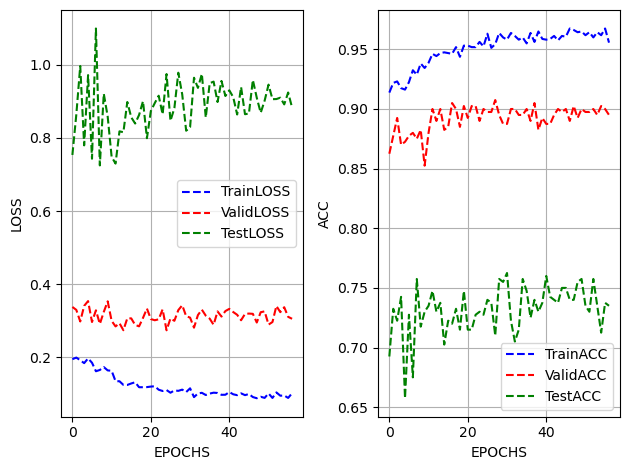

In [442]:

# MODEL.eval()
# xdata = range(self.EPOCH)
ydata1Loss = []
ydata1Acc = []

for loss, acc in HIST['Train']:
    ydata1Loss.append(loss)
    ydata1Acc.append(acc)
ydata2Loss = []
ydata2Acc = []
for loss, acc in HIST['Valid']:
    ydata2Loss.append(loss)
    ydata2Acc.append(acc)

ydata3Loss = []
ydata3Acc = []
for loss, acc in HIST['Test']:
    ydata3Loss.append(loss)
    ydata3Acc.append(acc)

fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(ydata1Loss, 'b--', label='TrainLOSS')
ax[1].plot(ydata1Acc, 'b--', label='TrainACC')

ax[0].plot(ydata2Loss, 'r--', label='ValidLOSS')
ax[1].plot(ydata2Acc, 'r--', label='ValidACC')

ax[0].plot(ydata3Loss, 'g--', label='TestLOSS')
ax[1].plot(ydata3Acc, 'g--', label='TestACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()

[7] 모델 활용 <hr>

In [440]:
## 방법-2) 저장된 층별 가중치와바이어스 로딩 
# WEIGHTS_FILE = MODEL_DIR+'weights_epoch39_0.907_nor.pt'
# WEIGHTS_FILE = MODEL_DIR+'fashion_weights_epoch13_0.905_3rd.pt'
# WEIGHTS_FILE = MODEL_DIR+'fashion_weights_epoch76_0.961.pt'
# WEIGHTS_FILE = MODEL_DIR+'weights_epoch15_r0.782_3rd.pt'
# WEIGHTS_FILE = MODEL_DIR+'weights_epoch39_0.907_nor.pt'
WEIGHTS_FILE = MODEL_DIR+'check_epoch30_n0.763_f.pt'


model2=wfCNN()
states=torch.load(WEIGHTS_FILE, weights_only=True)
model2.load_state_dict(states)

<All keys matched successfully>

- 예측함수 

In [447]:
128 * 6 * 6

4608

In [446]:
count = 0
for feature, target in testDS:
    feature = feature.unsqueeze(0)  # 배치 차원 추가 (1, C, H, W)
    output = model2(feature)  # 로짓 출력 (1, 1)
    
    predicted = (output > 0).long().squeeze()  # 0 또는 1 변환
    # print(predicted.item(), target)  # 정수 값 출력
    
    if predicted.item() == target:
        count += 1

accuracy = count / len(testDS)  # 정확도 계산
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7200


In [389]:
count = 0
for feature, target in testDS:
    feature = feature.unsqueeze(0)  # 배치 차원 추가 (1, C, H, W)
    output = model2(feature)  # (1, 1)
    # predicted = (output.sigmoid() > 0.5).long().squeeze()  # 0 또는 1 변환
    # print(predicted.item(), target)  # 정수 값 출력
    # print(output.item(), target)
    if output.item() == target:
        count+=1
print(count/4)


0.0


In [360]:
def get_idx_to_classes(classes):
    return {v:k for k, v in classes}